# Parte 3 · Modelado ML (15 pts)

Entrena un modelo que prediga `fla_churn90` con el dataset proporcionado.

**Requisitos** (ver `STATEMENT.md` para detalle y rúbrica):

1. Split estratificado y **temporal-aware**. Justifica cómo evitas leakage.
2. Pipeline con `ColumnTransformer` y al menos un modelo (LogReg o XGBoost/LightGBM).
3. Métricas correctas para clasificación binaria **desbalanceada**: AUC, PR-AUC, recall@k, calibración.
4. Interpretabilidad: top-5 features importantes con justificación. SHAP valorable.
5. Documenta en `DECISIONS.md`: ¿qué features descartaste y por qué? ¿hay alguna que sospeches que sea trampa?

> Si tu modelo da AUC > 0.95 en test, **investiga antes de celebrarlo**. Es muy probable leakage.

In [223]:
from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBClassifier

from sklearn.calibration import calibration_curve

SEED = 42
np.random.seed(SEED)

# Detect project root whether notebook is executed from project root or notebooks/
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

from src.parte1_pandas import load_clean

DATA_PATH = PROJECT_ROOT / "data" / "transactions_sample.csv"
OUTPUTS = PROJECT_ROOT / "outputs"
OUTPUTS.mkdir(exist_ok=True)

# print(f"Project root: {PROJECT_ROOT}")
print(f"Data path exists: {DATA_PATH.exists()}")

Data path exists: True


## 1 · Carga y EDA mínimo

Reutiliza `load_clean` de la Parte 1 (o carga aquí y limpia). Antes de modelar, mira los datos.

In [224]:
df = load_clean(DATA_PATH)

display(df.head())
display(df.attrs.get("load_clean_audit", {}))

print("Shape:", df.shape)

display(
    df["fla_churn90"]
    .value_counts(dropna=False, normalize=True)
    .rename("pct_rows")
    .to_frame()
)

,transaction_id,merchant_id,transaction_date,amount,status,channel,cancellation_reason,reference_date,fla_churn90,last_complaint_date,segment,mcc,dat_process,amount_raw,transaction_date_raw,reference_date_raw,last_complaint_date_raw,dat_process_raw
0,1,10007653,2025-09-11,18.5,approved,pos,<NA>,2025-09-30,0,NaT,SMB,4789,2025-09-11,"18,50",2025-09-11,2025-09-30,<NA>,2025-09-11
1,2,10009541,2024-03-16,16.81,approved,ecom,<NA>,2025-09-30,0,2025-05-14,SMB,7995,2024-03-16,"16,81",2024-03-16,2025-09-30,2025-05-14,2024-03-16
2,3,10006986,2024-04-30,65.4,approved,tef,<NA>,2025-09-30,0,NaT,SMB,5411,2024-04-30,"65,40",30/04/2024,2025-09-30,<NA>,2024-04-30
3,4,10002926,2024-11-23,86.97,denied,pos,<NA>,2025-09-30,0,2025-06-12,SMB,7995,2024-11-23,"86,97",2024-11-23,2025-09-30,2025-06-12,2024-11-23
4,5,10008646,2024-10-12,484.62,approved,ecom,<NA>,2025-09-30,0,NaT,Enterprise,5499,2024-10-12,"484,62",2024-10-12,2025-09-30,<NA>,2024-10-12


{'n_rows_raw': 204000,
 'amount_missing_raw': 6087,
 'amount_parse_failures': 0,
 'transaction_date_parse_failures': 0,
 'reference_date_parse_failures': 0,
 'last_complaint_date_parse_failures': 0,
 'dat_process_parse_failures': 0,
 'business_duplicate_rows_removed': 4180,
 'n_rows_clean': 199820}

Shape: (199820, 18)


,pct_rows
fla_churn90,
0,0.929562
1,0.070438


### Target a nivel merchant

Antes de modelar, compruebo que `fla_churn90` sea consistente dentro de cada merchant. Si un mismo merchant tuviera distintos valores de target, habría que resolver esa inconsistencia antes de construir el dataset de modelado.

In [225]:
target_consistency = (
    df.groupby("merchant_id")["fla_churn90"]
    .nunique()
    .rename("n_unique_target_values")
)

n_inconsistent = int((target_consistency > 1).sum())

print(f"Merchants con target inconsistente: {n_inconsistent:,}")

merchant_target = (
    df.groupby("merchant_id")["fla_churn90"]
    .first()
)

display(
    merchant_target
    .value_counts(normalize=True)
    .rename("pct_merchants")
    .to_frame()
)

Merchants con target inconsistente: 0


,pct_merchants
fla_churn90,
0,0.912543
1,0.087457


### Snapshots disponibles

Reviso cuántas `reference_date` existen en el dataset. Si solo hay un snapshot principal, no puedo hacer una validación out-of-time real entre snapshots. Por eso considero el split como temporal-aware por construcción de features: todas las variables predictivas se calculan usando únicamente información disponible hasta `reference_date`.

In [226]:
reference_date_summary = (
    df["reference_date"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("n_rows")
    .to_frame()
)

display(reference_date_summary)

print("Número de reference_date únicas:", df["reference_date"].nunique(dropna=True))

,n_rows
reference_date,
2025-09-30,199820


Número de reference_date únicas: 1


## 2 · Feature engineering y selección

Documenta en `DECISIONS.md` qué features incluyes y cuáles descartas, **y por qué**.

Pista: hay al menos una columna en el CSV que **no deberías usar** como feature aunque parezca útil. Piensa si la información está disponible *en el momento de la predicción*.

### Construcción de features a nivel merchant

Construyo un dataset de modelado con una fila por merchant. Las features se calculan con información temporalmente segura, es decir, usando solo transacciones con `transaction_date <= reference_date`.

No uso directamente columnas con riesgo de leakage como `cancellation_reason` o `last_complaint_date` sin filtrar. Si uso información de reclamos, solo utilizo una versión segura: reclamos con fecha menor o igual a `reference_date`.

In [227]:
def build_merchant_features(df: pd.DataFrame) -> pd.DataFrame:
    """Build merchant-level features using only information available up to reference_date."""
    required = {
        "merchant_id",
        "transaction_date",
        "reference_date",
        "amount",
        "status",
        "channel",
        "fla_churn90",
        "segment",
        "mcc",
    }
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    work = df.copy()

    # One snapshot per merchant. If multiple reference_dates existed, this should be revisited.
    merchant_reference = (
        work.groupby("merchant_id", as_index=False)["reference_date"]
        .max()
        .rename(columns={"reference_date": "merchant_reference_date"})
    )

    work = work.merge(merchant_reference, on="merchant_id", how="left")

    # Merchant-level target and stable context.
    merchant_base = (
        work.sort_values("merchant_id")
        .groupby("merchant_id", as_index=False)
        .agg(
            fla_churn90=("fla_churn90", "first"),
            segment=("segment", "first"),
            mcc=("mcc", "first"),
            merchant_reference_date=("merchant_reference_date", "max"),
        )
    )

    # Predictive-safe transaction history.
    safe_tx = work[
        work["transaction_date"].notna()
        & work["merchant_reference_date"].notna()
        & (work["transaction_date"] <= work["merchant_reference_date"])
    ].copy()

    features = merchant_base.copy()

    # ------------------------------------------------------------------
    # Recent vs previous windows
    # recent   = current reference month and previous 2 months
    # previous = months -5, -4, -3 relative to reference month
    # ------------------------------------------------------------------
    period_metrics = [
        "recent_tpv",
        "previous_tpv",
        "recent_n_tx",
        "previous_n_tx",
        "recent_approval_rate",
        "previous_approval_rate",
        "recent_bad_status_rate",
        "previous_bad_status_rate",
        "recent_pct_ecom_tpv",
        "previous_pct_ecom_tpv",
        "recent_pct_pix_tpv",
        "previous_pct_pix_tpv",
    ]

    if not safe_tx.empty:
        safe_tx["tx_month_index"] = (
            safe_tx["transaction_date"].dt.year * 12
            + safe_tx["transaction_date"].dt.month
        )
        safe_tx["ref_month_index"] = (
            safe_tx["merchant_reference_date"].dt.year * 12
            + safe_tx["merchant_reference_date"].dt.month
        )
        safe_tx["months_from_ref"] = (
            safe_tx["tx_month_index"] - safe_tx["ref_month_index"]
        )

        safe_tx["period"] = pd.NA
        safe_tx.loc[safe_tx["months_from_ref"].between(-2, 0), "period"] = "recent"
        safe_tx.loc[safe_tx["months_from_ref"].between(-5, -3), "period"] = "previous"

        period_tx = safe_tx[safe_tx["period"].notna()].copy()

        if not period_tx.empty:
            is_approved = period_tx["status"].eq("approved")
            is_bad_status = period_tx["status"].isin(["denied", "reversed"])

            period_tx["approved_amount"] = period_tx["amount"].where(is_approved, 0.0)
            period_tx["approved_tx"] = is_approved.astype(int)
            period_tx["bad_tx"] = is_bad_status.astype(int)

            period_tx["ecom_approved_amount"] = period_tx["approved_amount"].where(
                period_tx["channel"].eq("ecom"),
                0.0,
            )
            period_tx["pix_approved_amount"] = period_tx["approved_amount"].where(
                period_tx["channel"].eq("pix"),
                0.0,
            )

            period_agg = (
                period_tx.groupby(["merchant_id", "period"], as_index=False)
                .agg(
                    tpv=("approved_amount", "sum"),
                    n_tx=("merchant_id", "size"),
                    approved_tx=("approved_tx", "sum"),
                    bad_tx=("bad_tx", "sum"),
                    ecom_tpv=("ecom_approved_amount", "sum"),
                    pix_tpv=("pix_approved_amount", "sum"),
                )
            )

            period_agg["approval_rate"] = (
                period_agg["approved_tx"].div(period_agg["n_tx"]).fillna(0.0)
            )
            period_agg["bad_status_rate"] = (
                period_agg["bad_tx"].div(period_agg["n_tx"]).fillna(0.0)
            )
            period_agg["pct_ecom_tpv"] = (
                period_agg["ecom_tpv"]
                .div(period_agg["tpv"])
                .where(period_agg["tpv"] > 0, 0.0)
                .fillna(0.0)
            )
            period_agg["pct_pix_tpv"] = (
                period_agg["pix_tpv"]
                .div(period_agg["tpv"])
                .where(period_agg["tpv"] > 0, 0.0)
                .fillna(0.0)
            )

            period_wide = period_agg.pivot(
                index="merchant_id",
                columns="period",
                values=[
                    "tpv",
                    "n_tx",
                    "approval_rate",
                    "bad_status_rate",
                    "pct_ecom_tpv",
                    "pct_pix_tpv",
                ],
            )

            period_wide.columns = [
                f"{period}_{metric}" for metric, period in period_wide.columns
            ]
            period_wide = period_wide.reset_index()

            features = features.merge(period_wide, on="merchant_id", how="left")

    for column in period_metrics:
        if column not in features.columns:
            features[column] = 0.0

    features[period_metrics] = (
        features[period_metrics]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
    )

    # Derived deterioration ratios.
    features["tpv_drop_ratio"] = (
        (features["previous_tpv"] - features["recent_tpv"])
        .div(features["previous_tpv"])
        .where(features["previous_tpv"] > 0, 0.0)
        .clip(lower=0.0, upper=1.0)
        .fillna(0.0)
    )

    features["tx_drop_ratio"] = (
        (features["previous_n_tx"] - features["recent_n_tx"])
        .div(features["previous_n_tx"])
        .where(features["previous_n_tx"] > 0, 0.0)
        .clip(lower=0.0, upper=1.0)
        .fillna(0.0)
    )

    features["approval_rate_drop"] = (
        features["previous_approval_rate"] - features["recent_approval_rate"]
    ).clip(lower=0.0, upper=1.0).fillna(0.0)

    # ------------------------------------------------------------------
    # Transaction recency and cadence
    # ------------------------------------------------------------------
    if not safe_tx.empty:
        last_tx = (
            safe_tx.groupby("merchant_id", as_index=False)["transaction_date"]
            .max()
            .rename(columns={"transaction_date": "last_transaction_date"})
        )
        features = features.merge(last_tx, on="merchant_id", how="left")

        safe_tx_sorted = safe_tx.sort_values(["merchant_id", "transaction_date"]).copy()
        safe_tx_sorted["previous_transaction_date"] = (
            safe_tx_sorted.groupby("merchant_id")["transaction_date"].shift(1)
        )
        safe_tx_sorted["days_between_tx"] = (
            safe_tx_sorted["transaction_date"]
            - safe_tx_sorted["previous_transaction_date"]
        ).dt.days

        median_gap = (
            safe_tx_sorted.groupby("merchant_id", as_index=False)["days_between_tx"]
            .median()
            .rename(columns={"days_between_tx": "median_days_between_tx"})
        )
        features = features.merge(median_gap, on="merchant_id", how="left")
    else:
        features["last_transaction_date"] = pd.NaT
        features["median_days_between_tx"] = np.nan

    features["has_safe_tx_history"] = features["last_transaction_date"].notna()
    features["days_since_last_tx"] = (
        features["merchant_reference_date"] - features["last_transaction_date"]
    ).dt.days

    # ------------------------------------------------------------------
    # Safe complaints
    # ------------------------------------------------------------------
    if "last_complaint_date" in work.columns:
        safe_complaints = work[
            work["last_complaint_date"].notna()
            & work["merchant_reference_date"].notna()
            & (work["last_complaint_date"] <= work["merchant_reference_date"])
        ].copy()

        if not safe_complaints.empty:
            last_safe_complaint = (
                safe_complaints.groupby("merchant_id", as_index=False)[
                    "last_complaint_date"
                ]
                .max()
                .rename(columns={"last_complaint_date": "last_complaint_date_safe"})
            )

            features = features.merge(
                last_safe_complaint,
                on="merchant_id",
                how="left",
            )
        else:
            features["last_complaint_date_safe"] = pd.NaT
    else:
        features["last_complaint_date_safe"] = pd.NaT

    features["days_since_last_complaint_safe"] = (
        features["merchant_reference_date"] - features["last_complaint_date_safe"]
    ).dt.days
    features["has_safe_complaint"] = features["last_complaint_date_safe"].notna()

    return features

In [228]:
model_df = build_merchant_features(df)

print("Merchant-level modeling dataset shape:", model_df.shape)
display(model_df.head())

display(
    model_df["fla_churn90"]
    .value_counts(normalize=True)
    .rename("pct_merchants")
    .to_frame()
)

Merchant-level modeling dataset shape: (9982, 27)


,merchant_id,fla_churn90,segment,mcc,merchant_reference_date,previous_tpv,recent_tpv,previous_n_tx,recent_n_tx,previous_approval_rate,...,tpv_drop_ratio,tx_drop_ratio,approval_rate_drop,last_transaction_date,median_days_between_tx,has_safe_tx_history,days_since_last_tx,last_complaint_date_safe,days_since_last_complaint_safe,has_safe_complaint
0,10000000,0,SMB,5732,2025-09-30,300.91,0.00,2.0,1.0,1.0,...,1.0,0.5,1.0,2025-07-23,23.5,True,69.0,2025-07-23,69.0,True
1,10000001,0,SMB,5812,2025-09-30,0.00,114.26,0.0,3.0,0.0,...,0.0,0.0,0.0,2025-09-16,29.0,True,14.0,NaT,NaN,False
2,10000002,0,SMB,5411,2025-09-30,0.00,15.54,0.0,1.0,0.0,...,0.0,0.0,0.0,2025-07-05,70.0,True,87.0,NaT,NaN,False
3,10000003,0,SMB,4789,2025-09-30,0.00,23.59,0.0,1.0,0.0,...,0.0,0.0,0.0,2025-09-01,147.0,True,29.0,NaT,NaN,False
4,10000004,0,SMB,4789,2025-09-30,302.92,0.00,1.0,0.0,1.0,...,1.0,1.0,1.0,2025-06-02,151.0,True,120.0,2025-07-16,76.0,True


,pct_merchants
fla_churn90,
0,0.912543
1,0.087457


## Features descartadas

Descarto explícitamente columnas que pueden introducir leakage, memorización o ruido operativo:

- `fla_churn90`: es el target.
- `cancellation_reason`: parece información post-evento y está fuertemente asociada al target.
- `last_complaint_date` directa: puede contener fechas posteriores a `reference_date`.
- `merchant_id`: identificador, puede inducir memorización.
- `transaction_id`: identificador transaccional.
- `transaction_date` directa: se usa solo para construir agregados temporales seguros.
- `reference_date` directa: representa el snapshot, no una señal de comportamiento.
- `dat_process`: fecha operativa/procesamiento.
- columnas `*_raw`: se conservan para trazabilidad, no para modelado.

En lugar de esas columnas, uso agregados seguros a nivel merchant: volumen, actividad, approval rate, fricción operativa, mix de canal, cadencia transaccional y reclamos seguros.

In [229]:
target = "fla_churn90"

features_num = [
    "recent_tpv",
    "previous_tpv",
    "tpv_drop_ratio",
    "recent_n_tx",
    "previous_n_tx",
    "tx_drop_ratio",
    "recent_approval_rate",
    "previous_approval_rate",
    "approval_rate_drop",
    "recent_bad_status_rate",
    "previous_bad_status_rate",
    "recent_pct_ecom_tpv",
    "previous_pct_ecom_tpv",
    "recent_pct_pix_tpv",
    "previous_pct_pix_tpv",
    "days_since_last_tx",
    "median_days_between_tx",
    "days_since_last_complaint_safe",
]

features_cat = [
    "segment",
    "mcc",
    "has_safe_tx_history",
    "has_safe_complaint",
]

features = features_num + features_cat

X = model_df[features].copy()
y = model_df[target].astype(int)

# Forzar tipos numéricos.
for col in features_num:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# Forzar categóricas como texto/object.
# Incluye booleanos, para que OneHotEncoder los trate como categorías.
for col in features_cat:
    X[col] = X[col].astype("object")
    X[col] = X[col].where(X[col].notna(), "missing")
    X[col] = X[col].astype(str)

print("X shape:", X.shape)
print("y positive rate:", y.mean())

display(X.dtypes.to_frame("dtype"))
display(X[features_cat].head())

X shape: (9982, 22)
y positive rate: 0.08745742336205169


,dtype
recent_tpv,float64
previous_tpv,float64
tpv_drop_ratio,float64
recent_n_tx,float64
previous_n_tx,float64
tx_drop_ratio,float64
recent_approval_rate,float64
previous_approval_rate,float64
approval_rate_drop,float64
recent_bad_status_rate,float64


,segment,mcc,has_safe_tx_history,has_safe_complaint
0,SMB,5732,True,True
1,SMB,5812,True,False
2,SMB,5411,True,False
3,SMB,4789,True,False
4,SMB,4789,True,True


### Análisis de correlación entre features numéricas

Antes de entrenar los modelos, reviso la correlación Spearman entre features numéricas válidas para detectar redundancias fuertes.

Este análisis **no** se usa para decidir si una columna con posible leakage debe conservarse. Las columnas sospechosas se descartan por disponibilidad temporal y lógica de negocio. La correlación solo ayuda a entender redundancia entre features ya consideradas seguras.

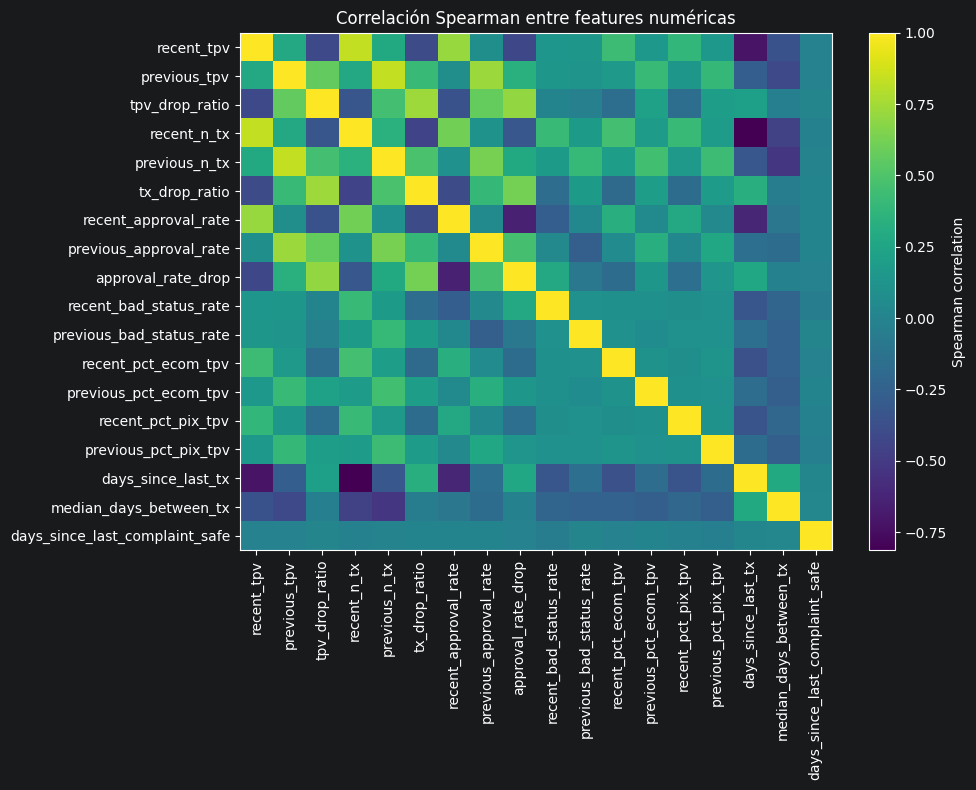

In [230]:
numeric_features_for_corr = [
    col for col in features_num
    if col in model_df.columns
]

corr = model_df[numeric_features_for_corr].corr(method="spearman")

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Spearman correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlación Spearman entre features numéricas")
plt.tight_layout()
plt.savefig(OUTPUTS / "feature_correlation_matrix.png", dpi=150)
plt.show()

In [231]:
corr_abs = corr.abs()
upper_mask = np.triu(np.ones(corr_abs.shape), k=1).astype(bool)

high_corr_pairs = (
    corr_abs
    .where(upper_mask)
    .stack()
    .reset_index()
)

high_corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "abs_spearman_corr",
]

high_corr_pairs = high_corr_pairs.sort_values(
    "abs_spearman_corr",
    ascending=False,
).reset_index(drop=True)

display(high_corr_pairs.head(20))

high_corr_pairs.to_csv(
    OUTPUTS / "feature_correlation_pairs.csv",
    index=False,
)

,feature_1,feature_2,abs_spearman_corr
0,previous_tpv,previous_n_tx,0.833249
1,recent_tpv,recent_n_tx,0.832342
2,recent_n_tx,days_since_last_tx,0.812839
3,tpv_drop_ratio,tx_drop_ratio,0.731012
4,previous_tpv,previous_approval_rate,0.728838
5,recent_tpv,recent_approval_rate,0.717273
6,recent_tpv,days_since_last_tx,0.716378
7,tpv_drop_ratio,approval_rate_drop,0.706940
8,recent_approval_rate,approval_rate_drop,0.646415
9,previous_n_tx,previous_approval_rate,0.629339


### Lectura de correlaciones

Las correlaciones más altas aparecen entre volumen y actividad (`tpv` y `n_tx`), algo esperable porque merchants con más transacciones suelen procesar más volumen. No observo correlaciones superiores a 0.90, por lo que no elimino variables automáticamente.

Mantengo estas features porque tienen interpretaciones de negocio distintas: TPV mide volumen económico, mientras que `n_tx` mide actividad operativa. En modelos de árboles, esta redundancia puede repartir importancia entre variables, por lo que interpretaré SHAP con cautela.

## 3 · Split — temporal-aware

Un split aleatorio puede filtrar información del futuro. ¿Cómo lo evitas? Justifica.

### Split temporal-aware

El dataset parece estar construido alrededor de un snapshot principal. Por eso no puedo hacer una validación out-of-time real entre snapshots distintos.

Para reducir leakage temporal, construyo todas las features usando únicamente información con fecha menor o igual a `reference_date`. Después uso un split estratificado a nivel merchant para conservar la proporción de churn en train y test.

In [232]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())

Train shape: (7486, 22)
Test shape: (2496, 22)
Train churn rate: 0.0874966604328079
Test churn rate: 0.08733974358974358


## 4 · Pipeline + entrenamiento

## Modelos

Entreno dos modelos:

1. **Logistic Regression** como baseline interpretable.
2. **XGBoost** como modelo tabular no lineal.

La Logistic Regression ayuda a tener una referencia simple. XGBoost puede capturar interacciones y relaciones no lineales entre señales de actividad, fricción e inactividad.

In [233]:
numeric_transformer_lr = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

numeric_transformer_tree = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_lr, features_num),
        ("cat", categorical_transformer, features_cat),
    ],
    remainder="drop",
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, features_num),
        ("cat", categorical_transformer, features_cat),
    ],
    remainder="drop",
)

In [234]:
logreg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_lr),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=SEED,
            ),
        ),
    ]
)

logreg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['recent_tpv', 'previous_tpv',
                                                   'tpv_drop_ratio',
                                                   'recent_n_tx',
                                                   'previous_n_tx',
                                                   'tx_drop_ratio',
                                                   'recent_approval_rate',
                                                   'previous_approval_rate',
                                                   'approval_rate_drop',
                                                   'recent_bad_status_rate',
                                                   'p...
                                                   'recent_pct_pix_tpv',
                                                   'previous_pct_pix_tpv',
                                                   'days_since_last_tx',
                                                   'median_days_between_tx',
                                                   'days_since_last_complaint_safe']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['segment', 'mcc',
                                                   'has_safe_tx_history',
                                                   'has_safe_complaint'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [235]:
scale_pos_weight = y_train.eq(0).sum() / y_train.eq(1).sum()

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        (
            "model",
            XGBClassifier(
                n_estimators=250,
                max_depth=3,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight,
                random_state=SEED,
                n_jobs=-1,
            ),
        ),
    ]
)

xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['recent_tpv', 'previous_tpv',
                                                   'tpv_drop_ratio',
                                                   'recent_n_tx',
                                                   'previous_n_tx',
                                                   'tx_drop_ratio',
                                                   'recent_approval_rate',
                                                   'previous_approval_rate',
                                                   'approval_rate_drop',
                                                   'recent_bad_status_rate',
                                                   'previous_bad_status_rate',
                                                   're...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=250, n_jobs=-1,
                               num_parallel_tree=None, random_state=42, ...))])

## Métricas

El target está desbalanceado, por lo que `accuracy` no es una métrica suficiente. Evalúo con:

- ROC-AUC;
- Average Precision / PR-AUC;
- Brier score;
- precision@k y recall@k.

Las métricas @k son útiles porque en churn normalmente se prioriza una lista reducida de merchants para acciones comerciales.

In [236]:
def recall_precision_at_k(y_true, y_score, k_frac: float) -> dict:
    y_true_array = np.asarray(y_true)
    n = len(y_true_array)
    k = max(1, int(np.ceil(n * k_frac)))

    order = np.argsort(-y_score)
    top_idx = order[:k]
    y_top = y_true_array[top_idx]

    total_positives = y_true_array.sum()

    recall = y_top.sum() / total_positives if total_positives > 0 else np.nan
    precision = y_top.mean()

    return {
        f"recall_at_{int(k_frac * 100)}pct": float(recall),
        f"precision_at_{int(k_frac * 100)}pct": float(precision),
    }


def evaluate_model(name: str, pipeline, X_test, y_test) -> dict:
    y_score = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        "model": name,
        "roc_auc": float(roc_auc_score(y_test, y_score)),
        "average_precision": float(average_precision_score(y_test, y_score)),
        "brier_score": float(brier_score_loss(y_test, y_score)),
        "positive_rate_test": float(y_test.mean()),
    }

    for k_frac in [0.01, 0.05, 0.10]:
        metrics.update(recall_precision_at_k(y_test, y_score, k_frac))

    if metrics["roc_auc"] > 0.95:
        print(
            f"Warning: {name} has ROC-AUC > 0.95. "
            "This should trigger a leakage review."
        )

    return metrics

In [237]:
metrics_logreg = evaluate_model(
    "logistic_regression",
    logreg_pipeline,
    X_test,
    y_test,
)

metrics_xgb = evaluate_model(
    "xgboost",
    xgb_pipeline,
    X_test,
    y_test,
)

metrics_df = pd.DataFrame([metrics_logreg, metrics_xgb])
display(metrics_df)

baseline_positive_rate = float(y_test.mean())

baseline_metrics = {
    "model": "baseline_constant_positive_rate",
    "roc_auc": 0.5,
    "average_precision": baseline_positive_rate,
    "brier_score": float(
        brier_score_loss(
            y_test,
            np.full(shape=len(y_test), fill_value=baseline_positive_rate),
        )
    ),
    "positive_rate_test": baseline_positive_rate,
}

metrics_with_baseline_df = pd.DataFrame(
    [baseline_metrics, metrics_logreg, metrics_xgb]
)

metrics_with_baseline_df["ap_lift_vs_baseline"] = (
    metrics_with_baseline_df["average_precision"] / baseline_positive_rate
)

metrics_with_baseline_df["brier_delta_vs_baseline"] = (
    metrics_with_baseline_df["brier_score"] - baseline_metrics["brier_score"]
)

display(metrics_with_baseline_df)

metrics = {
    "baseline": baseline_metrics,
    "models": [metrics_logreg, metrics_xgb],
}

(OUTPUTS / "model_metrics.json").write_text(
    json.dumps(metrics, indent=2),
    encoding="utf-8",
)

,model,roc_auc,average_precision,brier_score,positive_rate_test,recall_at_1pct,precision_at_1pct,recall_at_5pct,precision_at_5pct,recall_at_10pct,precision_at_10pct
0,logistic_regression,0.617428,0.113666,0.233977,0.08734,0.013761,0.12,0.059633,0.104,0.12844,0.112
1,xgboost,0.601030,0.115016,0.212172,0.08734,0.013761,0.12,0.045872,0.080,0.12844,0.112


,model,roc_auc,average_precision,brier_score,positive_rate_test,recall_at_1pct,precision_at_1pct,recall_at_5pct,precision_at_5pct,recall_at_10pct,precision_at_10pct,ap_lift_vs_baseline,brier_delta_vs_baseline
0,baseline_constant_positive_rate,0.500000,0.087340,0.079712,0.08734,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000
1,logistic_regression,0.617428,0.113666,0.233977,0.08734,0.013761,0.12,0.059633,0.104,0.12844,0.112,1.301429,0.154265
2,xgboost,0.601030,0.115016,0.212172,0.08734,0.013761,0.12,0.045872,0.080,0.12844,0.112,1.316876,0.132461


1159

In [238]:
best_model_name = (
    metrics_df.sort_values("average_precision", ascending=False)
    .iloc[0]["model"]
)

best_pipeline = {
    "logistic_regression": logreg_pipeline,
    "xgboost": xgb_pipeline,
}[best_model_name]

print("Best model selected by Average Precision:", best_model_name)

Best model selected by Average Precision: xgboost


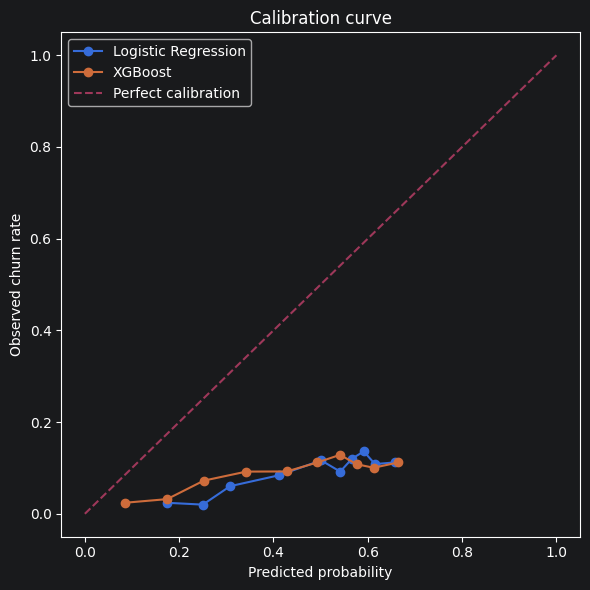

In [239]:
plt.figure(figsize=(6, 6))

for name, pipeline in [
    ("Logistic Regression", logreg_pipeline),
    ("XGBoost", xgb_pipeline),
]:
    y_score = pipeline.predict_proba(X_test)[:, 1]
    prob_true, prob_pred = calibration_curve(
        y_test,
        y_score,
        n_bins=10,
        strategy="quantile",
    )

    plt.plot(prob_pred, prob_true, marker="o", label=name)

plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Predicted probability")
plt.ylabel("Observed churn rate")
plt.title("Calibration curve")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUTS / "calibration_curve.png", dpi=150)
plt.show()

### Lectura de métricas

Los modelos muestran señal moderada, no una separación fuerte. XGBoost obtiene una Average Precision ligeramente superior a Logistic Regression, por eso lo selecciono como modelo final, aunque la diferencia es pequeña.

El ROC-AUC está alrededor de 0.60–0.62, lejos de valores sospechosamente altos. Esto reduce la sospecha de leakage fuerte, aunque no la elimina.

El Brier score es peor de lo deseable para interpretar las salidas como probabilidades calibradas. Esto es esperable en parte porque se usan estrategias de balanceo (`class_weight` y `scale_pos_weight`) que ayudan al ranking, pero pueden distorsionar la calibración. Por tanto, interpreto el modelo principalmente como ranking de riesgo, no como probabilidad calibrada de churn.

### Selección del modelo final

Selecciono el modelo final por Average Precision, porque el target está desbalanceado y me interesa priorizar correctamente merchants con mayor riesgo. XGBoost queda ligeramente por encima de Logistic Regression en Average Precision, aunque la diferencia es pequeña.

Por tanto, no interpreto XGBoost como claramente superior, sino como el modelo final de esta iteración. En una validación real, compararía estabilidad en otros snapshots y calibración antes de decidir un modelo productivo.

## 6 · Interpretabilidad

Top-5 features importantes con justificación. SHAP valorable.

> Recuerda: importancia (SHAP, feature_importances) **NO es causalidad**. Documéntalo si toca.

### Interpretabilidad con SHAP

Uso SHAP para interpretar el modelo final a nivel global y obtener el top-5 de features más importantes.

No añado LIME para evitar introducir una dependencia adicional. SHAP ya está disponible en el entorno y cubre el requisito de interpretabilidad global. Las importancias indican asociación con la predicción, no causalidad.

In [240]:
preprocessor = best_pipeline.named_steps["preprocessor"]
model = best_pipeline.named_steps["model"]

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

sample_size = min(1000, X_test_transformed.shape[0])
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(
    X_test_transformed.shape[0],
    size=sample_size,
    replace=False,
)

X_shap = X_test_transformed[sample_idx]

In [241]:
if best_model_name == "xgboost":
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)
else:
    explainer = shap.LinearExplainer(model, X_train_transformed)
    shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_array = shap_values[1]
else:
    shap_array = np.asarray(shap_values)

# Some explainers may return a 3D array for binary classification.
if shap_array.ndim == 3:
    shap_array = shap_array[:, :, 1]

mean_abs_shap = np.abs(shap_array).mean(axis=0)

feature_importance = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "mean_abs_shap": mean_abs_shap,
        }
    )
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

top5_features = feature_importance.head(5)

display(top5_features)

feature_importance.to_csv(
    OUTPUTS / "feature_importance.csv",
    index=False,
)

,feature,mean_abs_shap
0,cat__has_safe_complaint_False,0.351519
1,num__previous_tpv,0.156565
2,num__days_since_last_complaint_safe,0.147177
3,num__days_since_last_tx,0.143391
4,num__median_days_between_tx,0.100961


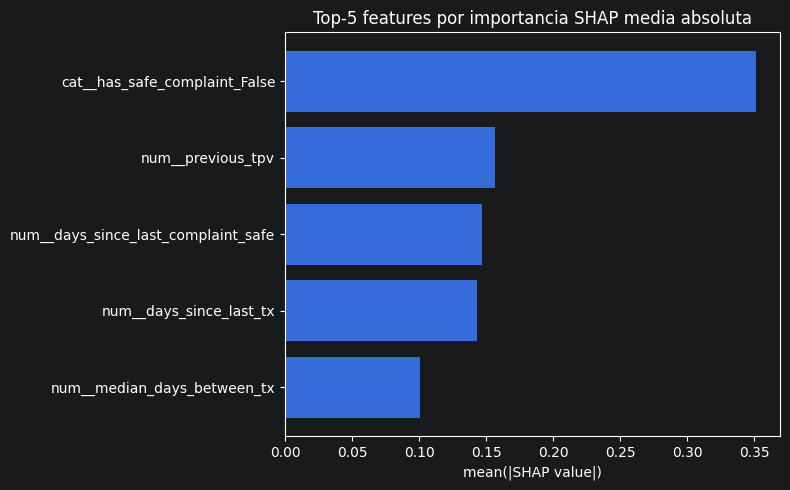

In [242]:
plt.figure(figsize=(8, 5))
plt.barh(
    top5_features["feature"][::-1],
    top5_features["mean_abs_shap"][::-1],
)
plt.title("Top-5 features por importancia SHAP media absoluta")
plt.xlabel("mean(|SHAP value|)")
plt.tight_layout()
plt.savefig(OUTPUTS / "feature_importance.png", dpi=150)
plt.show()

### Interpretación del top-5

El top-5 de SHAP se interpreta como las variables que más influyen globalmente en las predicciones del modelo final. No implica causalidad.

El modelo final seleccionado es XGBoost y las variables más importantes según SHAP son:

1. **`has_safe_complaint_False`**
   Indica si el merchant no tiene un reclamo observable antes o en `reference_date`. Esta variable aparece como importante, pero la interpreto con cautela porque las fechas de reclamo tenían riesgo temporal en el dataset original. No la considero causal; solo indica que el patrón de reclamos seguros/no seguros está asociado con las predicciones del modelo.

2. **`previous_tpv`**
   Representa el volumen aprobado del periodo anterior. Puede capturar tamaño o actividad base del merchant. Merchants con diferente volumen histórico pueden tener patrones de churn distintos.

3. **`days_since_last_complaint_safe`**
   Mide la distancia temporal al último reclamo seguro antes del snapshot. Puede capturar fricción o insatisfacción reciente, pero solo se usa tras aplicar el filtro temporal `last_complaint_date <= reference_date`.

4. **`days_since_last_tx`**
   Mide inactividad reciente. Un mayor número de días desde la última transacción puede indicar menor uso del producto o posible abandono.

5. **`median_days_between_tx`**
   Captura la cadencia habitual del merchant. Ayuda a diferenciar merchants naturalmente poco frecuentes de merchants que se han vuelto inactivos respecto a su propio patrón.

Estas importancias indican asociación con la predicción, no causalidad. Además, como varias features de reclamos aparecen entre las más importantes, mantengo la decisión de interpretarlas con cautela y validaría con negocio cuándo se registran realmente esos eventos.

### Sanity check sin features de reclamos

Como las features relacionadas con reclamos aparecen entre las más importantes, entreno una versión adicional de XGBoost sin `has_safe_complaint` ni `days_since_last_complaint_safe`.

Este experimento no sustituye al modelo final, pero ayuda a comprobar si el rendimiento depende demasiado de una familia de variables potencialmente delicada. Si el rendimiento cae mucho, documentaría que el modelo depende de información de reclamos y que esa señal debe validarse con negocio antes de usarse.

In [243]:
features_num_no_complaint = [
    col for col in features_num
    if col != "days_since_last_complaint_safe"
]

features_cat_no_complaint = [
    col for col in features_cat
    if col != "has_safe_complaint"
]

X_train_no_complaint = X_train[features_num_no_complaint + features_cat_no_complaint]
X_test_no_complaint = X_test[features_num_no_complaint + features_cat_no_complaint]

preprocessor_tree_no_complaint = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, features_num_no_complaint),
        ("cat", categorical_transformer, features_cat_no_complaint),
    ],
    remainder="drop",
)

xgb_no_complaint_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree_no_complaint),
        (
            "model",
            XGBClassifier(
                n_estimators=250,
                max_depth=3,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight,
                random_state=SEED,
                n_jobs=-1,
            ),
        ),
    ]
)

xgb_no_complaint_pipeline.fit(X_train_no_complaint, y_train)

metrics_xgb_no_complaint = evaluate_model(
    "xgboost_no_complaint_features",
    xgb_no_complaint_pipeline,
    X_test_no_complaint,
    y_test,
)

display(
    pd.DataFrame(
        [
            metrics_xgb,
            metrics_xgb_no_complaint,
        ]
    )
)

sanity_check_metrics = {
    "xgboost": metrics_xgb,
    "xgboost_no_complaint_features": metrics_xgb_no_complaint,
}

(OUTPUTS / "sanity_check_no_complaint_metrics.json").write_text(
    json.dumps(sanity_check_metrics, indent=2),
    encoding="utf-8",
)

,model,roc_auc,average_precision,brier_score,positive_rate_test,recall_at_1pct,precision_at_1pct,recall_at_5pct,precision_at_5pct,recall_at_10pct,precision_at_10pct
0,xgboost,0.601030,0.115016,0.212172,0.08734,0.013761,0.12,0.045872,0.080,0.128440,0.112
1,xgboost_no_complaint_features,0.527511,0.098270,0.219406,0.08734,0.022936,0.20,0.055046,0.096,0.105505,0.092


920

### Lectura del sanity check sin reclamos

Al eliminar `has_safe_complaint` y `days_since_last_complaint_safe`, el ROC-AUC y la Average Precision bajan, lo que sugiere que las variables de reclamos aportan señal global al modelo. Sin embargo, algunas métricas top-k no empeoran e incluso mejoran ligeramente, por lo que no interpreto estas variables como una señal perfecta ni suficiente por sí sola.

Esto refuerza la decisión de mantenerlas solo como features temporalmente filtradas y documentarlas como variables sensibles que deberían validarse con negocio antes de producción.

### Interpretabilidad local con SHAP

En una explicación local, cada feature empuja la predicción del merchant hacia arriba o hacia abajo respecto al valor base del modelo.

- Un valor SHAP **positivo** aumenta el score de churn.
- Un valor SHAP **negativo** reduce el score de churn.
- La magnitud absoluta indica cuánto pesa esa feature en la predicción local.

Por eso, en cada caso reviso tanto las señales que aumentan el riesgo como las señales que lo moderan. Una feature con SHAP negativo no significa que sea incorrecta ni que sea mala. Significa que, para ese merchant concreto, el valor de esa variable se parece más al patrón que el modelo asocia con menor riesgo de churn.

Para una observación true positive, selecciono preferentemente un merchant con `fla_churn90 = 1` y score alto. Si no existe, uso el merchant con mayor score.

Esta explicación local ayuda a entender por qué el modelo asignó riesgo a un caso específico. No sustituye la evaluación global ni implica causalidad.

In [244]:
test_scores = best_pipeline.predict_proba(X_test)[:, 1]

test_scored = pd.DataFrame(
    {
        "row_index": X_test.index,
        "y_true": y_test.to_numpy(),
        "y_score": test_scores,
    }
).sort_values("y_score", ascending=False)

positive_candidates = test_scored[test_scored["y_true"].eq(1)]

if not positive_candidates.empty:
    selected_row_index = positive_candidates.iloc[0]["row_index"]
else:
    selected_row_index = test_scored.iloc[0]["row_index"]

local_pos = X_test.index.get_loc(selected_row_index)

X_local = X_test.iloc[[local_pos]]
X_local_transformed = preprocessor.transform(X_local)

if best_model_name == "xgboost":
    local_shap_values = explainer.shap_values(X_local_transformed)
else:
    local_shap_values = explainer.shap_values(X_local_transformed)

if isinstance(local_shap_values, list):
    local_shap_array = np.asarray(local_shap_values[1])
else:
    local_shap_array = np.asarray(local_shap_values)

if local_shap_array.ndim == 3:
    local_shap_array = local_shap_array[:, :, 1]

local_shap_row = local_shap_array[0]

local_explanation = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "shap_value": local_shap_row,
            "abs_shap_value": np.abs(local_shap_row),
        }
    )
    .sort_values("abs_shap_value", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

selected_score = float(best_pipeline.predict_proba(X_local)[:, 1][0])
selected_true = int(y_test.loc[selected_row_index])

print("Selected local explanation row index:", selected_row_index)
print("True label:", selected_true)
print("Predicted score:", selected_score)

display(X_local)
display(local_explanation)

local_explanation.to_csv(
    OUTPUTS / "local_shap_explanation.csv",
    index=False,
)

Selected local explanation row index: 139.0
True label: 1
Predicted score: 0.8195732831954956


,recent_tpv,previous_tpv,tpv_drop_ratio,recent_n_tx,previous_n_tx,tx_drop_ratio,recent_approval_rate,previous_approval_rate,approval_rate_drop,recent_bad_status_rate,...,previous_pct_ecom_tpv,recent_pct_pix_tpv,previous_pct_pix_tpv,days_since_last_tx,median_days_between_tx,days_since_last_complaint_safe,segment,mcc,has_safe_tx_history,has_safe_complaint
139,360.25,395.67,0.089519,3.0,4.0,0.25,0.666667,0.75,0.083333,0.333333,...,0.092956,0.706759,0.210226,16.0,33.0,NaN,SMB,5311,True,False


,feature,shap_value,abs_shap_value
0,num__recent_pct_pix_tpv,0.297107,0.297107
1,cat__has_safe_complaint_False,0.203977,0.203977
2,num__days_since_last_tx,0.176374,0.176374
3,num__median_days_between_tx,0.151665,0.151665
4,num__recent_tpv,0.113312,0.113312
5,num__previous_bad_status_rate,0.103353,0.103353
6,num__previous_pct_pix_tpv,0.080083,0.080083
7,num__recent_n_tx,-0.075517,0.075517
8,num__previous_pct_ecom_tpv,0.070056,0.070056
9,num__previous_tpv,0.054591,0.054591


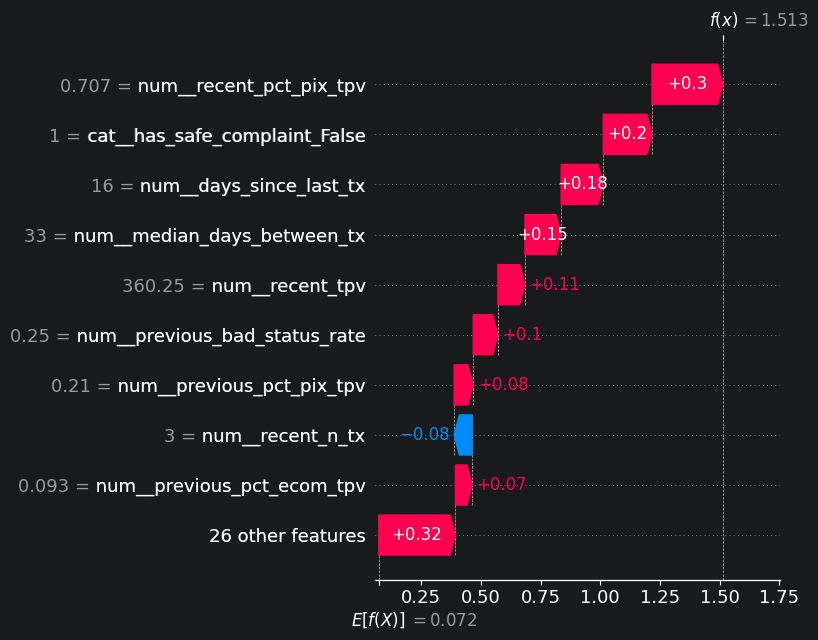

In [245]:
base_value = explainer.expected_value

if isinstance(base_value, (list, np.ndarray)):
    base_value = np.asarray(base_value).ravel()[0]

local_explanation_obj = shap.Explanation(
    values=local_shap_row,
    base_values=base_value,
    data=X_local_transformed[0],
    feature_names=feature_names,
)

shap.plots.waterfall(
    local_explanation_obj,
    max_display=10,
    show=False,
)

plt.tight_layout()
plt.savefig(OUTPUTS / "local_shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretación local del true positive

El merchant seleccionado es un **true positive**: el modelo le asigna un score alto de churn (`0.8196`) y el target real indica `fla_churn90 = 1`.

Las principales variables que empujan la predicción hacia mayor riesgo son:

- `recent_pct_pix_tpv`: el peso reciente del canal PIX tiene la mayor contribución positiva local. Para este merchant, el modelo interpreta este patrón de canal como una señal asociada a mayor riesgo.
- `has_safe_complaint_False`: la ausencia de un reclamo seguro observable antes del snapshot también empuja el score hacia arriba. Esta señal debe interpretarse con cautela, porque las variables de reclamos ya fueron identificadas como sensibles y deberían validarse con negocio.
- `days_since_last_tx`: el merchant lleva 16 días desde la última transacción segura, lo que el modelo interpreta como una señal de menor actividad reciente.
- `median_days_between_tx`: la cadencia histórica del merchant también contribuye positivamente, ayudando al modelo a contextualizar si el tiempo desde la última transacción es normal o no para este merchant.
- `recent_tpv` y `previous_bad_status_rate`: aportan señales adicionales de volumen/fricción operativa.

También aparece una variable con contribución negativa:

- `recent_n_tx`: esta feature reduce ligeramente el score de churn. Para este merchant, tener 3 transacciones recientes parece actuar como una señal que modera el riesgo, porque indica que todavía existe actividad observable en el periodo reciente.

En conjunto, aunque `recent_n_tx` reduce algo el score, las señales positivas son más fuertes y el modelo termina asignando una predicción alta. Esto es coherente con un true positive: hay algunas señales que moderan el riesgo, pero predominan las señales asociadas a churn.

Esta explicación no implica causalidad. Solo muestra cómo el modelo combina las señales de este merchant concreto para llegar a un score alto.

### Interpretación local de un false positive

Además del true positive, reviso un merchant con score alto pero `fla_churn90 = 0`. Este caso ayuda a entender posibles falsas alarmas del modelo.

Un false positive en churn no significa necesariamente que el modelo sea inútil: puede representar un merchant con señales de riesgo que finalmente no abandonó, quizá porque fue retenido, porque el problema se resolvió o porque la ventana de 90 días no capturó el abandono. Aun así, estos casos son importantes porque en producción podrían generar acciones comerciales innecesarias.

La comparación entre true positive y false positive ayuda a ver si el modelo está usando señales razonables o si está sobrerreaccionando ante patrones concretos, por ejemplo reclamos, inactividad o cambios de canal.

In [246]:
false_positive_candidates = test_scored[
    test_scored["y_true"].eq(0)
].sort_values("y_score", ascending=False)

if not false_positive_candidates.empty:
    fp_row_index = false_positive_candidates.iloc[0]["row_index"]
    fp_local_pos = X_test.index.get_loc(fp_row_index)

    X_fp_local = X_test.iloc[[fp_local_pos]]
    X_fp_local_transformed = preprocessor.transform(X_fp_local)

    if best_model_name == "xgboost":
        fp_shap_values = explainer.shap_values(X_fp_local_transformed)
    else:
        fp_shap_values = explainer.shap_values(X_fp_local_transformed)

    if isinstance(fp_shap_values, list):
        fp_shap_array = np.asarray(fp_shap_values[1])
    else:
        fp_shap_array = np.asarray(fp_shap_values)

    if fp_shap_array.ndim == 3:
        fp_shap_array = fp_shap_array[:, :, 1]

    fp_shap_row = fp_shap_array[0]

    fp_local_explanation = (
        pd.DataFrame(
            {
                "feature": feature_names,
                "shap_value": fp_shap_row,
                "abs_shap_value": np.abs(fp_shap_row),
            }
        )
        .sort_values("abs_shap_value", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )

    fp_selected_score = float(best_pipeline.predict_proba(X_fp_local)[:, 1][0])
    fp_selected_true = int(y_test.loc[fp_row_index])

    print("False positive row index:", fp_row_index)
    print("True label:", fp_selected_true)
    print("Predicted score:", fp_selected_score)

    display(X_fp_local)
    display(fp_local_explanation)

    fp_local_explanation.to_csv(
        OUTPUTS / "local_shap_false_positive_explanation.csv",
        index=False,
    )
else:
    print("No false positive candidates found.")

False positive row index: 9257.0
True label: 0
Predicted score: 0.7736077308654785


,recent_tpv,previous_tpv,tpv_drop_ratio,recent_n_tx,previous_n_tx,tx_drop_ratio,recent_approval_rate,previous_approval_rate,approval_rate_drop,recent_bad_status_rate,...,previous_pct_ecom_tpv,recent_pct_pix_tpv,previous_pct_pix_tpv,days_since_last_tx,median_days_between_tx,days_since_last_complaint_safe,segment,mcc,has_safe_tx_history,has_safe_complaint
9257,90.32,409.25,0.779304,1.0,6.0,0.833333,1.0,1.0,0.0,0.0,...,0.183482,1.0,0.188418,20.0,14.5,NaN,SMB,5411,True,False


,feature,shap_value,abs_shap_value
0,num__days_since_last_tx,0.265029,0.265029
1,num__recent_pct_pix_tpv,0.202721,0.202721
2,cat__has_safe_complaint_False,0.170401,0.170401
3,num__tx_drop_ratio,0.164295,0.164295
4,num__previous_pct_ecom_tpv,0.097420,0.097420
5,num__previous_pct_pix_tpv,0.082233,0.082233
6,num__previous_n_tx,0.081519,0.081519
7,num__recent_tpv,-0.054256,0.054256
8,num__previous_tpv,0.045643,0.045643
9,cat__mcc_7011,0.038066,0.038066


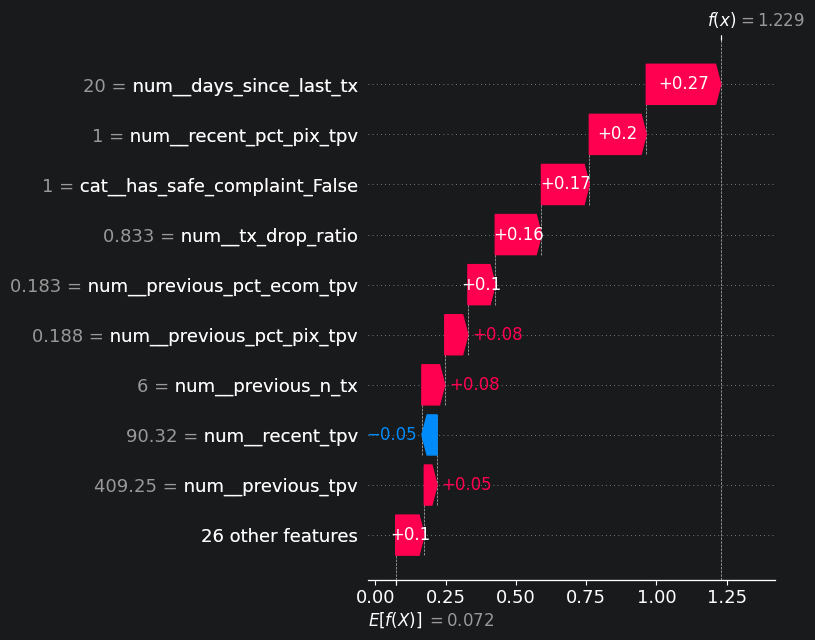

In [247]:
if not false_positive_candidates.empty:
    fp_local_explanation_obj = shap.Explanation(
        values=fp_shap_row,
        base_values=base_value,
        data=X_fp_local_transformed[0],
        feature_names=feature_names,
    )

    shap.plots.waterfall(
        fp_local_explanation_obj,
        max_display=10,
        show=False,
    )

    plt.tight_layout()
    plt.savefig(
        OUTPUTS / "local_shap_false_positive_waterfall.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

### Interpretación local del false positive

El merchant seleccionado es un **false positive**: el modelo le asigna un score alto de churn (`0.7736`), pero el target real indica `fla_churn90 = 0`.

Las variables que más empujan el score hacia mayor riesgo son:

- `days_since_last_tx`: el merchant lleva 20 días desde la última transacción segura. El modelo interpreta esta inactividad reciente como una señal relevante de riesgo.
- `recent_pct_pix_tpv`: todo el TPV reciente del merchant viene del canal PIX (`recent_pct_pix_tpv = 1.0`), y para este caso el modelo asocia ese patrón con mayor riesgo.
- `has_safe_complaint_False`: la ausencia de reclamo seguro observable antes del snapshot también empuja el score hacia arriba. Igual que en el true positive, esta señal debe interpretarse con cautela.
- `tx_drop_ratio`: el número de transacciones cae de 6 en el periodo anterior a 1 en el periodo reciente, lo que genera una señal fuerte de deterioro de actividad.
- `previous_pct_ecom_tpv`, `previous_pct_pix_tpv` y `previous_n_tx`: ayudan a contextualizar el patrón anterior del merchant.

También aparece una feature con contribución negativa:

- `recent_tpv`: esta variable reduce ligeramente el score de churn. Aunque el TPV reciente es bajo (`90.32`), el hecho de que todavía exista volumen aprobado reciente actúa como una señal que modera el riesgo. Es decir, el merchant no está completamente inactivo: aún procesa algo de volumen.

El modelo se equivoca porque las señales positivas (inactividad, caída fuerte de transacciones, cambio de mix de canal y ausencia de reclamo seguro) pesan más que la señal negativa de `recent_tpv`. Este caso es útil porque muestra una posible falsa alarma: el merchant tiene señales razonables de riesgo, pero finalmente no churneó dentro de la ventana de 90 días.

Un false positive no significa necesariamente que el modelo haya aprendido una señal absurda. Puede ser un merchant con deterioro real que fue retenido, que recuperó actividad después, o cuyo abandono no ocurrió dentro de la ventana exacta observada. En producción, estos casos serían importantes porque podrían generar acciones comerciales innecesarias.

## 7 · Persistencia

Guarda el modelo entrenado en `outputs/model.pkl` (joblib) y un mini `model_card.md` con: features, target, métricas, supuestos, limitaciones.

Guardo los artefactos mínimos de la Parte 3:

- métricas del modelo;
- importancia de features;
- gráfico de importancia;
- matriz/pares de correlación;
- modelo entrenado;
- model card.

In [248]:
joblib.dump(best_pipeline, OUTPUTS / "model.pkl")

['C:\\Users\\Pep Biel\\Documents\\GitHub\\getnet-ai-graduate-assessment\\outputs\\model.pkl']

In [249]:
def df_to_markdown_safe(df: pd.DataFrame) -> str:
    try:
        return df.to_markdown(index=False)
    except ImportError:
        return df.to_string(index=False)


metrics_table = df_to_markdown_safe(metrics_with_baseline_df)
top5_table = df_to_markdown_safe(top5_features)

model_card = f"""# Model card · Parte 3

## Objetivo

Predecir `fla_churn90` a nivel merchant usando señales disponibles hasta `reference_date`.

## Grano del dataset

Una fila por merchant. Las transacciones se agregan a features de comportamiento antes del snapshot.

## Target

`fla_churn90`: 1 si el merchant churneó en los 90 días posteriores al snapshot.

## Modelo seleccionado

`{best_model_name}`

## Features usadas

### Numéricas

{features_num}

### Categóricas

{features_cat}

## Features descartadas

- `cancellation_reason`: posible leakage post-evento.
- `last_complaint_date` directa: puede contener información posterior al snapshot.
- `merchant_id`: identificador, riesgo de memorización.
- `transaction_id`: identificador transaccional.
- `transaction_date` directa: se usa solo para construir agregados temporales seguros.
- `reference_date` directa: snapshot, no señal de comportamiento.
- `dat_process`: fecha operativa/procesamiento.
- columnas `*_raw`: trazabilidad, no features.

## Métricas

{metrics_table}

## Interpretabilidad

Se calcularon importancias globales con SHAP sobre una muestra del test set. Las importancias indican asociación con la predicción, no causalidad.

Top-5 features:

{top5_table}

## Sanity check sin features de reclamos

También entrené una versión de XGBoost sin `has_safe_complaint` ni `days_since_last_complaint_safe`. Al quitarlas, baja la Average Precision y el ROC-AUC, lo que sugiere que aportan señal. Aun así, estas variables deben validarse con negocio porque proceden de una columna que ya se había identificado como sensible a leakage temporal.

## Interpretabilidad local

Además de la importancia global, generé explicaciones locales con SHAP:

- un true positive de alto score, para entender un caso donde el modelo asigna alto riesgo y el merchant efectivamente churneó
- un false positive de alto score, para revisar qué señales pueden generar falsas alarmas.

En las explicaciones revisé tanto contribuciones positivas como negativas. Las contribuciones positivas aumentan el score de churn del merchant, mientras que las negativas lo reducen. Esta separación ayuda a entender que una predicción no depende de una única variable, sino del balance entre señales de riesgo y señales que moderan ese riesgo.

Estas explicaciones ayudan a auditar el comportamiento del modelo caso a caso. No sustituyen la evaluación global ni implican causalidad.

## Limitaciones

- Si solo existe un snapshot principal, el split no es una validación temporal real entre snapshots.
- La validación es estratificada a nivel merchant, no out-of-time.
- Las features se construyen evitando información posterior a `reference_date`, pero la robustez debería validarse en otro periodo.
- El score del modelo no debe usarse directamente para decisiones automáticas sin calibración y validación de negocio.
- SHAP indica asociación con la predicción, no causalidad.
- Las probabilidades no están necesariamente calibradas, el modelo debe interpretarse principalmente como ranking de riesgo.
- Las features relacionadas con reclamos aparecen entre las más importantes, por lo que deberían validarse con negocio antes de usarse en producción.
- Los false positives deben revisarse con negocio: pueden ser falsas alarmas reales o merchants con señales de deterioro que finalmente no churnearon en la ventana de 90 días.
"""

(OUTPUTS / "model_card.md").write_text(model_card, encoding="utf-8")

5036

In [250]:
print("Generated artifacts:")
for path in [
    OUTPUTS / "model_metrics.json",
    OUTPUTS / "feature_importance.csv",
    OUTPUTS / "feature_importance.png",
    OUTPUTS / "feature_correlation_pairs.csv",
    OUTPUTS / "feature_correlation_matrix.png",
    OUTPUTS / "model.pkl",
    OUTPUTS / "model_card.md",
    OUTPUTS / "calibration_curve.png",
    OUTPUTS / "sanity_check_no_complaint_metrics.json",
    OUTPUTS / "local_shap_explanation.csv",
    OUTPUTS / "local_shap_waterfall.png",
    OUTPUTS / "local_shap_false_positive_explanation.csv",
    OUTPUTS / "local_shap_false_positive_waterfall.png",
]:
    print(path.name, "->", path.exists())

Generated artifacts:
model_metrics.json -> True
feature_importance.csv -> True
feature_importance.png -> True
feature_correlation_pairs.csv -> True
feature_correlation_matrix.png -> True
model.pkl -> True
model_card.md -> True
calibration_curve.png -> True
sanity_check_no_complaint_metrics.json -> True
local_shap_explanation.csv -> True
local_shap_waterfall.png -> True
local_shap_false_positive_explanation.csv -> True
local_shap_false_positive_waterfall.png -> True
